In [2]:


import os
import json
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from jiwer import wer

def load_metadata(jsonl_path):
    meta_map = {}

    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                row = json.loads(line)

                key = row.get("key")
                if key is None:
                    continue
                row.pop("key", None)
                cleaned = {}
                for k, v in row.items():
                    if k == "duration":
                        try:
                            cleaned[k] = float(v)
                        except:
                            cleaned[k] = np.nan
                    else:
                            val = str(v).strip().lower()

                            if val in ["", "nan", "none", "null"]:
                                val = "unknown"
                            cleaned[k] = val
                meta_map[key] = cleaned
            except Exception:
                continue
    return meta_map

In [ ]:
metadata = "/home/ashley-bravo/SLAM-LLM/examples/asr_librispeech/data/Fairspeech/fairspeech_test_metadata_full.jsonl"
meta_map = load_metadata(metadata)

df = pd.DataFrame.from_dict(meta_map, orient="index")
df.reset_index(names="key", inplace=True)

print(df.head())
print(df.columns)

                                       key  gender      age first_language  \
0  fs_ca1920051b7fdc279c45b5211b261cf0_ASR  female  18 - 22        english   
1  fs_61b469ebfd9e2ee5ec3295b23d282ec4_ASR  female  31 - 45        english   
2  fs_eb7e37f0cf0c1b5e3587f2ee6a4bd3ba_ASR    male  18 - 22        english   
3  fs_d1354340600029ae49d0efac5d1dcb14_ASR    male  18 - 22        english   
4  fs_46b92c6d41ef7b63d1f0ccb40bb1d3c5_ASR    male  31 - 45        english   

  socioeconomic_bkgd                  ethnicity  duration  
0                low                      white  2.720000  
1             medium                      white  4.080000  
2                low                      white  5.000000  
3             medium  black or african american  5.154438  
4                low  black or african american  5.360000  
Index(['key', 'gender', 'age', 'first_language', 'socioeconomic_bkgd',
       'ethnicity', 'duration'],
      dtype='object')


In [5]:
print(df["socioeconomic_bkgd"].value_counts())

socioeconomic_bkgd
low         14780
medium       9823
affluent     1867
Name: count, dtype: int64


In [6]:
affluent_df = df[df["socioeconomic_bkgd"] == "affluent"]

print("Total affluent:", len(affluent_df))

Total affluent: 1867


In [7]:
gender_counts = affluent_df["gender"].value_counts()

print(gender_counts)

print(
    affluent_df["gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

gender
female    1191
male       676
Name: count, dtype: int64
gender
female    63.79
male      36.21
Name: proportion, dtype: float64


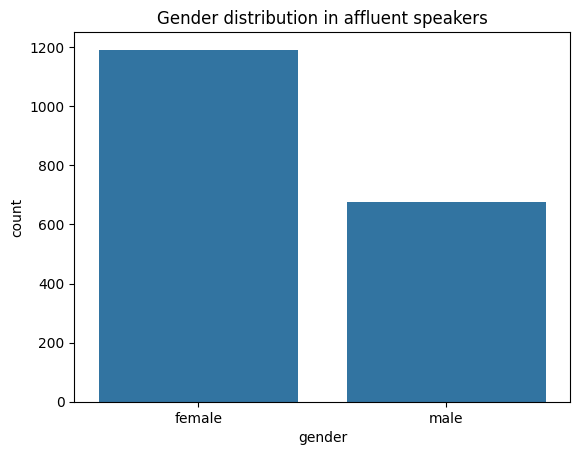

In [8]:
sns.countplot(data=affluent_df, x="gender")
plt.title("Gender distribution in affluent speakers")
plt.show()

In [9]:
print(df["age"].unique()[:20])

['18 - 22' '31 - 45' '46 - 65' '23 - 30']


In [10]:
print(
    affluent_df["age"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

age
46 - 65    40.71
31 - 45    39.15
23 - 30    15.10
18 - 22     5.03
Name: proportion, dtype: float64


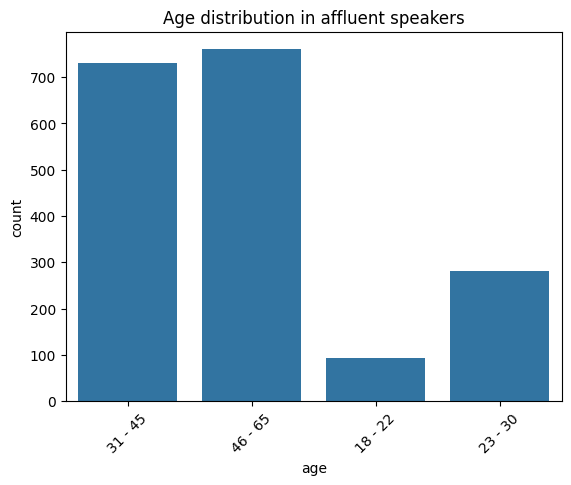

In [11]:
sns.countplot(data=affluent_df, x="age")
plt.xticks(rotation=45)
plt.title("Age distribution in affluent speakers")
plt.show()

ethnicity
asian, south asian or asian american                  35.24
native american, american indian, or alaska native    23.94
white                                                 17.57
black or african american                             12.64
native hawaiian or other pacific islander              4.50
hispanic, latino, or spanish                           3.64
middle eastern or north african                        2.46
Name: proportion, dtype: float64


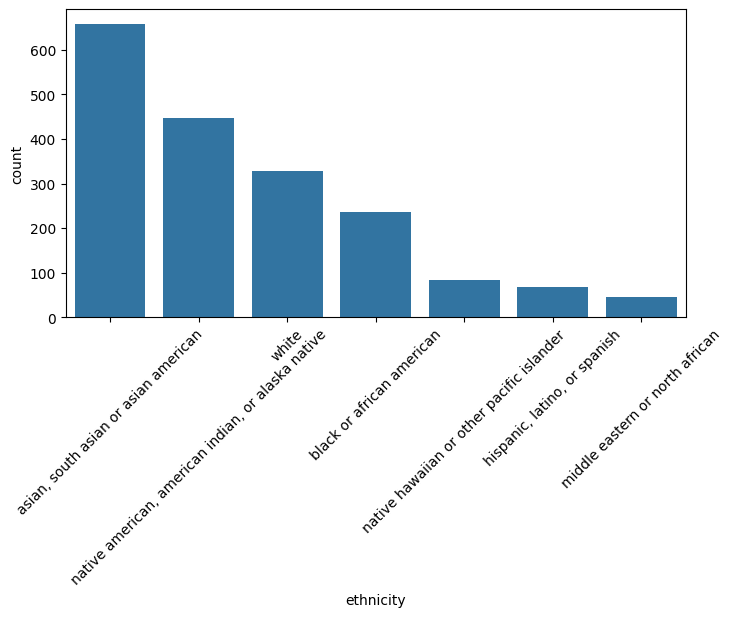

In [12]:
ethnicity_stats = (
    affluent_df["ethnicity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(ethnicity_stats)


plt.figure(figsize=(8,4))

sns.countplot(
    data=affluent_df,
    x="ethnicity",
    order=affluent_df["ethnicity"].value_counts().index
)

plt.xticks(rotation=45)
plt.show()

In [13]:
print(
    affluent_df["first_language"]
    .value_counts()
    .head(20)
)

print(
    affluent_df["first_language"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .head(20)
)

first_language
english      1193
mandarin      146
hindi         137
spanish       115
french         50
tagalog        49
korean         48
urdu           44
cantonese      43
german         42
Name: count, dtype: int64
first_language
english      63.90
mandarin      7.82
hindi         7.34
spanish       6.16
french        2.68
tagalog       2.62
korean        2.57
urdu          2.36
cantonese     2.30
german        2.25
Name: proportion, dtype: float64


In [14]:
pd.crosstab(
    df["socioeconomic_bkgd"],
    df["gender"],
    normalize="index"
) * 100

gender,female,male
socioeconomic_bkgd,,
affluent,63.792180,36.207820
low,61.123139,38.876861
medium,42.716075,57.283925


In [15]:
pd.crosstab(
    df["socioeconomic_bkgd"],
    df["age"],
    normalize="index"
) * 100

age,18 - 22,23 - 30,31 - 45,46 - 65
socioeconomic_bkgd,,,,
affluent,5.034815,15.104446,39.153723,40.707017
low,22.327470,20.717185,38.876861,18.078484
medium,4.601446,8.388476,64.063932,22.946147


In [16]:
pd.crosstab(
    df["socioeconomic_bkgd"],
    df["ethnicity"],
    normalize="index"
) * 100

ethnicity,"asian, south asian or asian american",black or african american,"hispanic, latino, or spanish",middle eastern or north african,"native american, american indian, or alaska native",native hawaiian or other pacific islander,white
socioeconomic_bkgd,,,,,,,
affluent,35.243706,12.640600,3.642207,2.463846,23.942153,4.499197,17.568291
low,15.446549,22.875507,12.158322,3.132612,17.767253,3.870095,24.749662
medium,9.294513,42.654993,9.661000,2.443245,15.870915,3.186399,16.888934


In [17]:
pd.crosstab(
    df["socioeconomic_bkgd"],
    df["first_language"],
    normalize="index"
) * 100

first_language,arabic,cantonese,creole,dutch,english,english/turkish,filipino,french,german,hindi,...,nepali,portuguese,russian,spanish,tagalog,turkish,ukrainian,unknown,urdu,vietnamese
socioeconomic_bkgd,,,,,,,,,,,,,,,,,,,,,
affluent,0.000000,2.303160,0.000000,0.000000,63.899304,0.00000,0.000000,2.678093,2.249598,7.337975,...,0.000000,0.000000,0.000000,6.159614,2.624531,0.000000,0.000000,0.000000,2.356722,0.000000
low,0.947226,0.676590,0.317997,0.297700,80.771313,0.14885,0.000000,0.656292,0.317997,0.649526,...,0.338295,0.527740,0.663058,7.564276,0.622463,0.311231,0.196211,0.838972,0.622463,0.324763
medium,0.000000,0.488649,0.000000,0.498829,85.472870,0.00000,0.509009,0.274865,0.478469,0.000000,...,0.000000,0.956938,0.000000,6.403339,0.498829,0.000000,0.000000,0.468289,0.000000,0.386847
